In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [51]:

sns.set_style("whitegrid")

df = pd.read_csv("../data/processed/cyclone_monthly_1891_2025.csv")

df.head()

,YEAR,MONTH,cyclones_total,max_wind,severe_total,disturbances_total,severity_ratio,disturbance_ratio,target,cyclone_5yr_avg,season_monsoon,season_post_monsoon,season_pre_monsoon,season_winter,cyclones_prev_month,cyclones_prev_3mo,cyclones_prev_6mo
0,1891,1,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,False,False,False,True,NaN,NaN,NaN
1,1891,2,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,False,False,False,True,0.0,NaN,NaN
2,1891,3,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,False,False,True,False,0.0,0.000000,NaN
3,1891,4,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,False,False,True,False,0.0,0.000000,NaN
4,1891,5,1.0,0.0,0.0,2.0,0.0,1.0,0,1.0,False,False,True,False,0.0,0.333333,NaN


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   YEAR                 1620 non-null   int64  
 1   MONTH                1620 non-null   int64  
 2   cyclones_total       1620 non-null   float64
 3   max_wind             1620 non-null   float64
 4   severe_total         1620 non-null   float64
 5   disturbances_total   1620 non-null   float64
 6   severity_ratio       1620 non-null   float64
 7   disturbance_ratio    1620 non-null   float64
 8   target               1620 non-null   int64  
 9   cyclone_5yr_avg      923 non-null    float64
 10  season_monsoon       1620 non-null   bool   
 11  season_post_monsoon  1620 non-null   bool   
 12  season_pre_monsoon   1620 non-null   bool   
 13  season_winter        1620 non-null   bool   
 14  cyclones_prev_month  1619 non-null   float64
 15  cyclones_prev_3mo    1618 non-null   f

In [53]:
df.describe()

,YEAR,MONTH,cyclones_total,max_wind,severe_total,disturbances_total,severity_ratio,disturbance_ratio,target,cyclone_5yr_avg,cyclones_prev_month,cyclones_prev_3mo,cyclones_prev_6mo
count,1620.000000,1620.000000,1620.000000,1620.000000,1620.000000,1620.000000,1620.000000,1620.000000,1620.000000,923.000000,1619.000000,1618.000000,1615.000000
mean,1958.000000,6.500000,1.119753,9.198765,1.000617,2.239506,0.363385,0.708932,0.051235,1.973235,1.120445,1.121137,1.123117
std,38.982107,3.453118,1.280048,24.933983,5.377589,2.560096,1.944895,0.640541,0.220544,0.285968,1.280141,0.965648,0.713066
min,1891.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1924.000000,3.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.716667,0.000000,0.333333,0.500000
50%,1958.000000,6.500000,1.000000,0.000000,0.000000,2.000000,0.000000,1.000000,0.000000,1.928571,1.000000,1.000000,1.000000
75%,1992.000000,9.250000,2.000000,0.000000,0.000000,4.000000,0.000000,1.333333,0.000000,2.233333,2.000000,1.666667,1.666667
max,2025.000000,12.000000,8.000000,150.000000,65.000000,16.000000,21.000000,1.777778,1.000000,2.600000,8.000000,4.666667,3.333333


In [54]:
df["target"].value_counts()

target
0    1537
1      83
Name: count, dtype: int64

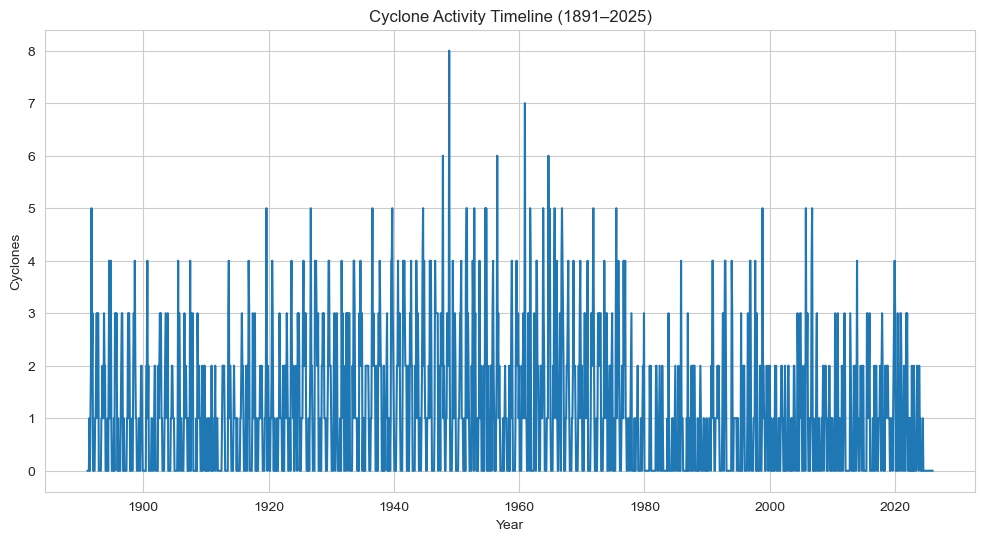

In [55]:
plt.figure(figsize=(12,6))

plt.plot(df["YEAR"] + df["MONTH"]/12, df["cyclones_total"])

plt.title("Cyclone Activity Timeline (1891–2025)")
plt.xlabel("Year")
plt.ylabel("Cyclones")

plt.show()

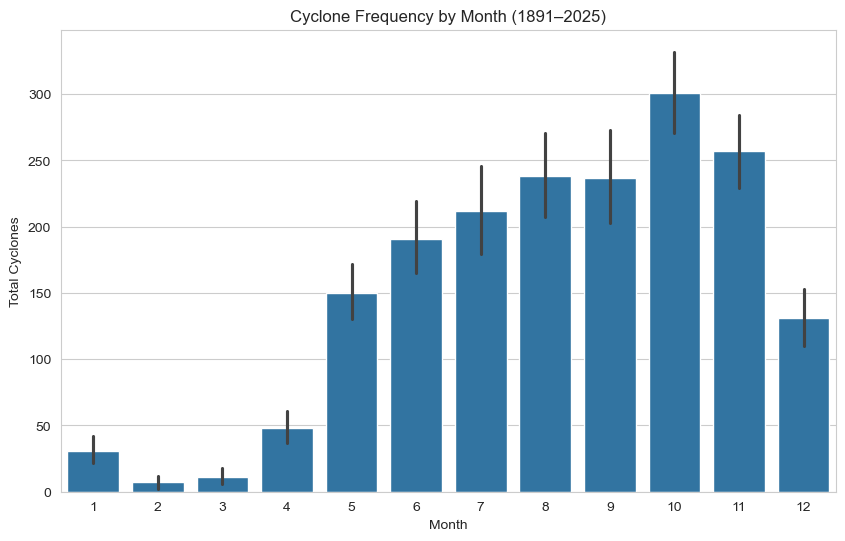

In [56]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="MONTH",
    y="cyclones_total",
    data=df,
    estimator=sum
)

plt.title("Cyclone Frequency by Month (1891–2025)")
plt.xlabel("Month")
plt.ylabel("Total Cyclones")

plt.show()

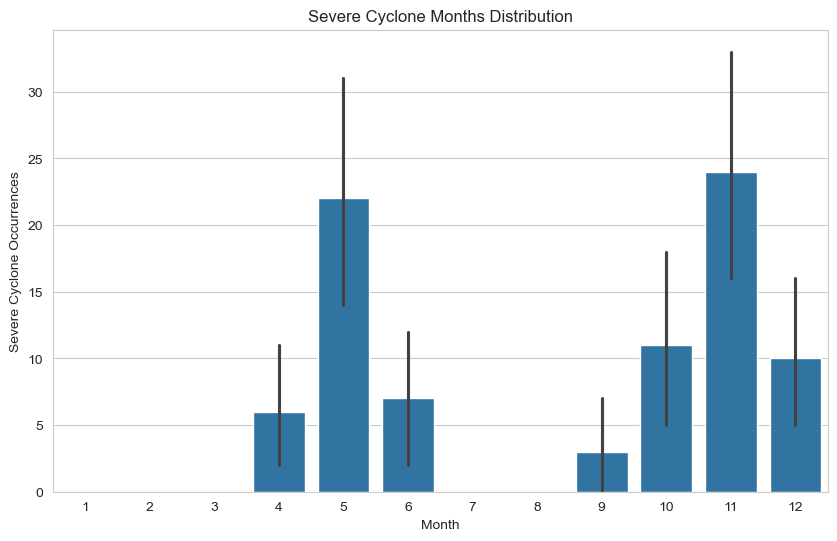

In [57]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="MONTH",
    y="target",
    data=df,
    estimator=sum
)

plt.title("Severe Cyclone Months Distribution")
plt.xlabel("Month")
plt.ylabel("Severe Cyclone Occurrences")

plt.show()

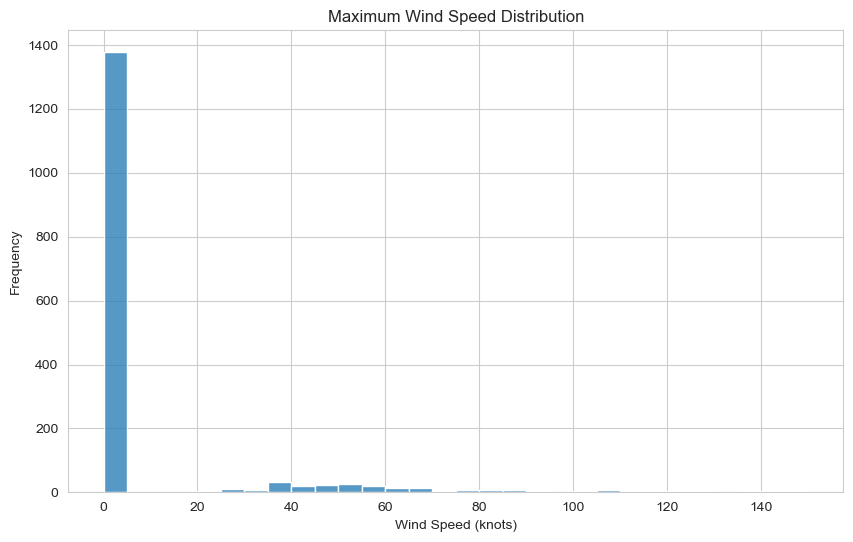

In [58]:
plt.figure(figsize=(10,6))

sns.histplot(df["max_wind"], bins=30)

plt.title("Maximum Wind Speed Distribution")
plt.xlabel("Wind Speed (knots)")
plt.ylabel("Frequency")

plt.show()

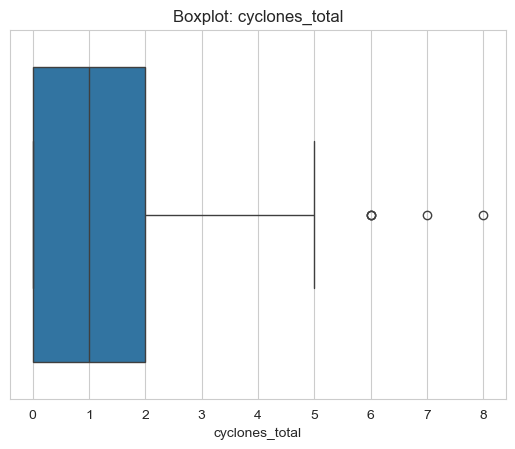

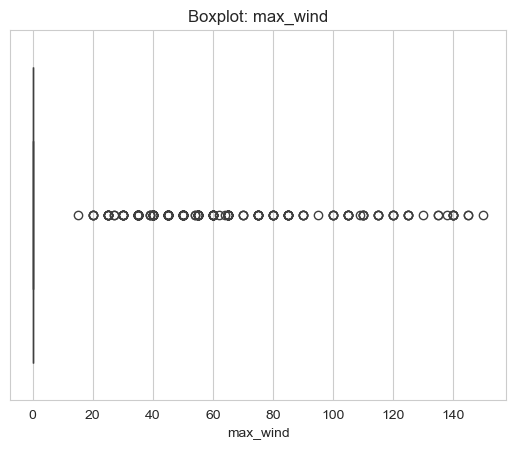

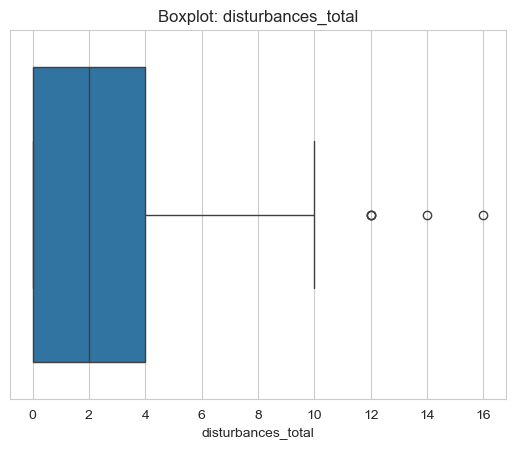

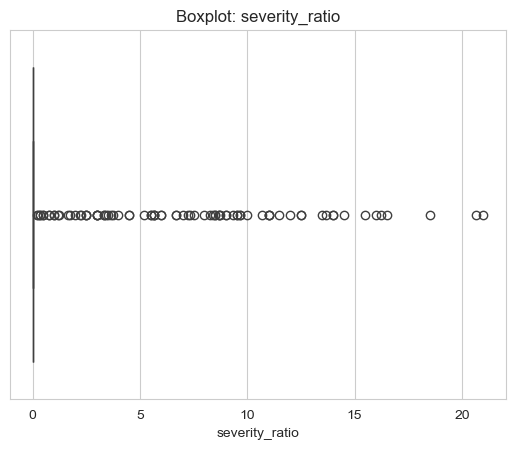

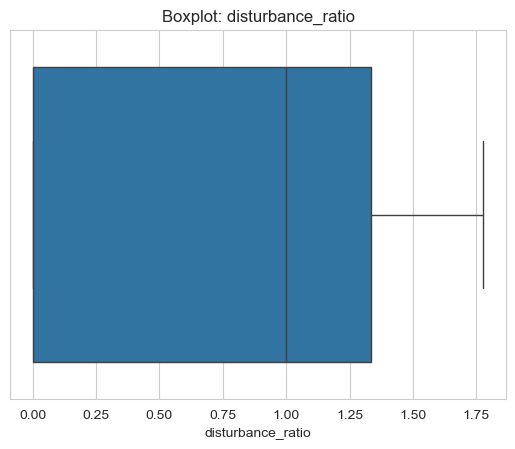

In [59]:
features = [
    "cyclones_total",
    "max_wind",
    "disturbances_total",
    "severity_ratio",
    "disturbance_ratio"
]

for f in features:
    
    plt.figure()
    
    sns.boxplot(x=df[f])
    
    plt.title(f"Boxplot: {f}")
    
    plt.show()

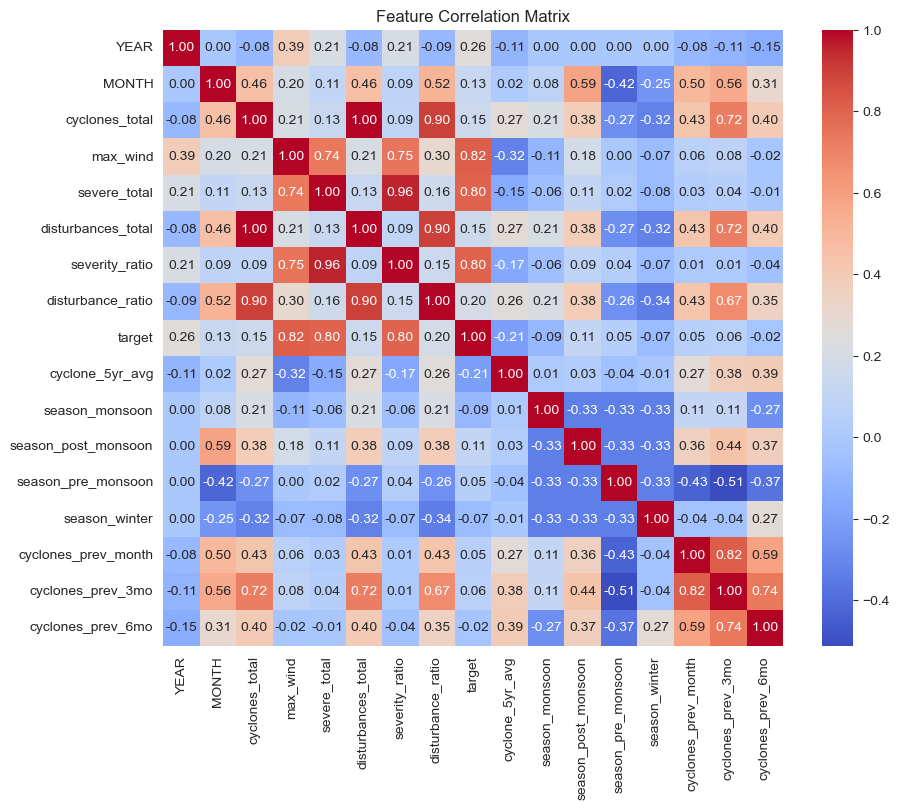

In [60]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")

plt.show()

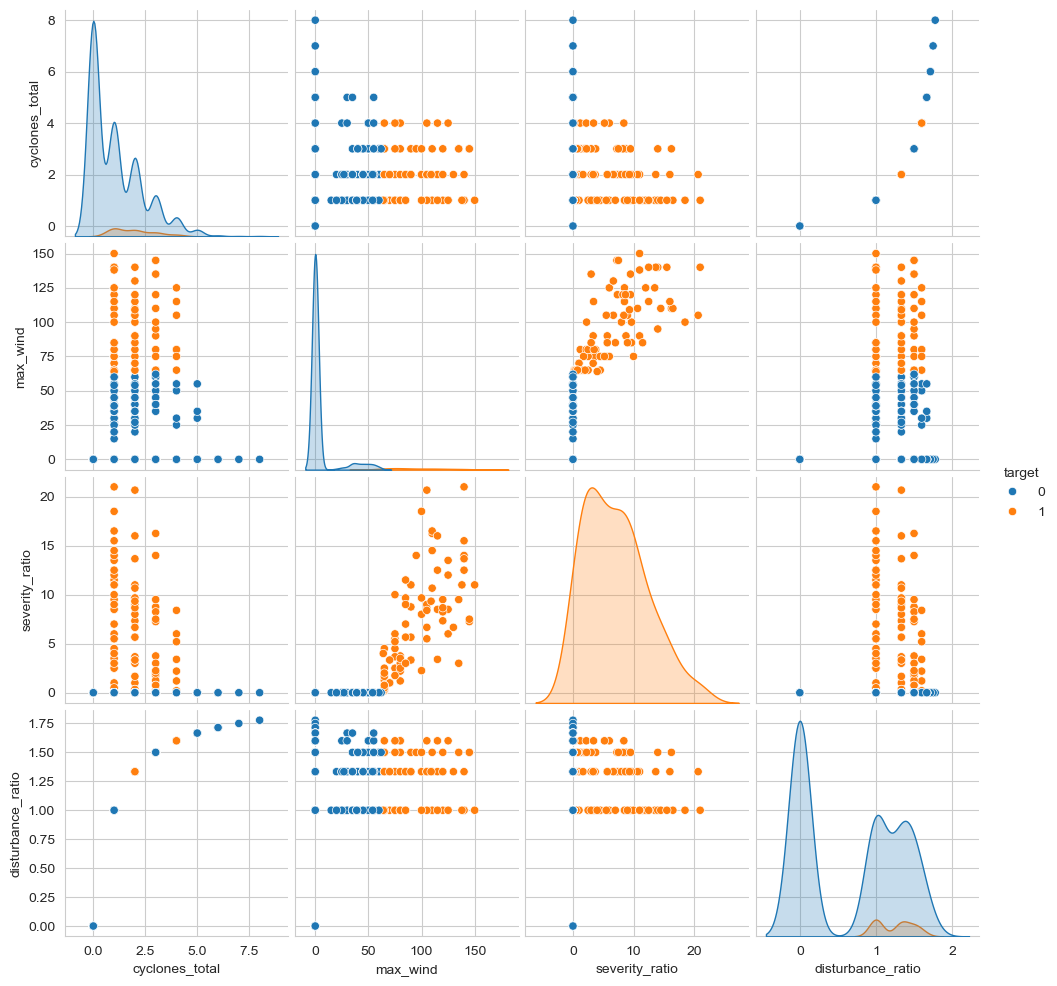

In [61]:
sns.pairplot(
    df[
        [
            "cyclones_total",
            "max_wind",
            "severity_ratio",
            "disturbance_ratio",
            "target"
        ]
    ],
    hue="target"
)

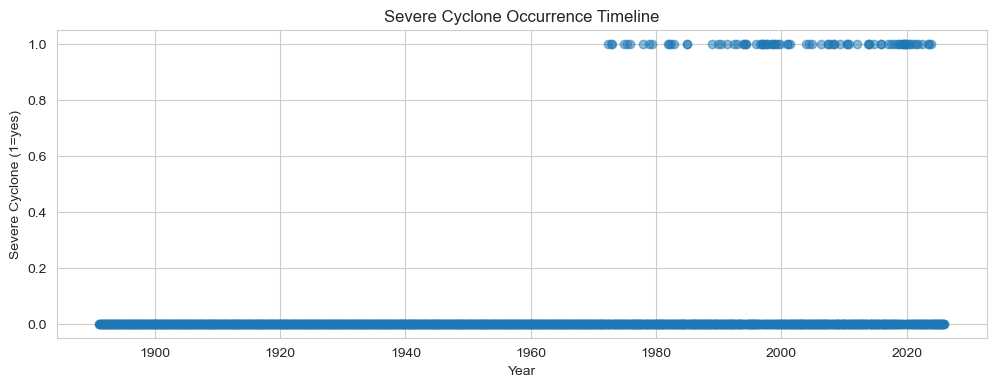

In [62]:
plt.figure(figsize=(12,4))

plt.scatter(
    df["YEAR"] + df["MONTH"]/12,
    df["target"],
    alpha=0.5
)

plt.title("Severe Cyclone Occurrence Timeline")
plt.xlabel("Year")
plt.ylabel("Severe Cyclone (1=yes)")

plt.show()

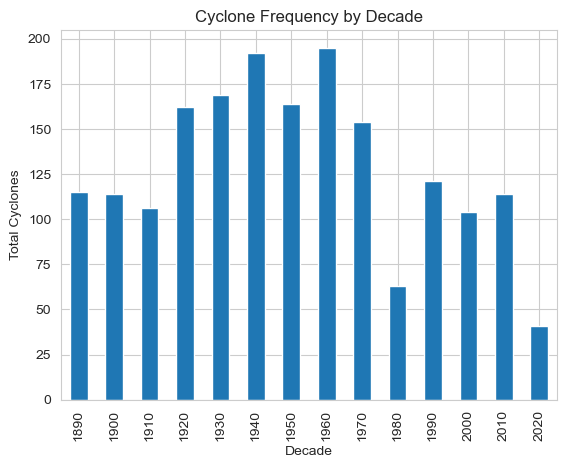

In [63]:
df["decade"] = (df["YEAR"] // 10) * 10

decade_counts = df.groupby("decade")["cyclones_total"].sum()

decade_counts.plot(kind="bar")

plt.title("Cyclone Frequency by Decade")
plt.xlabel("Decade")
plt.ylabel("Total Cyclones")

plt.show()

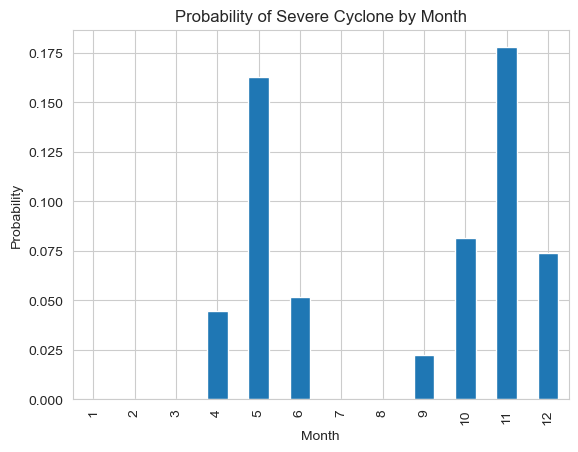

In [64]:
monthly_prob = df.groupby("MONTH")["target"].mean()

monthly_prob.plot(kind="bar")

plt.title("Probability of Severe Cyclone by Month")
plt.xlabel("Month")
plt.ylabel("Probability")

plt.show()

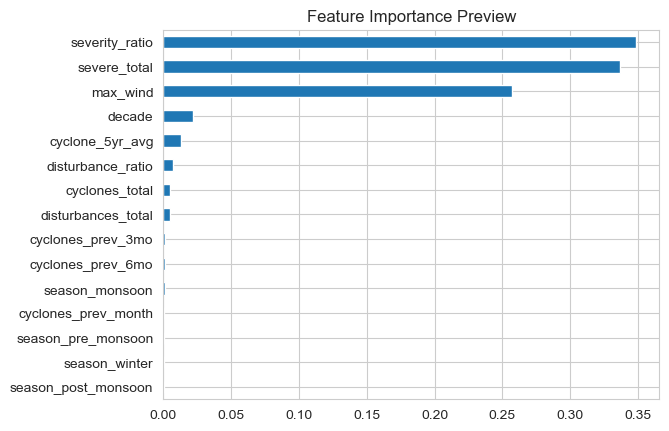

In [65]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop(columns=["target","YEAR","MONTH"])
y = df["target"]

rf = RandomForestClassifier()

rf.fit(X,y)

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot.barh()

plt.title("Feature Importance Preview")

plt.show()

In [66]:
drop_cols = [
    "YEAR",
    "MONTH",
    "decade",
    "max_wind",
    "severe_total",
    "severity_ratio"
]
df = df.drop(columns=drop_cols)
df["cyclone_5yr_avg"] = df["cyclone_5yr_avg"].fillna(method="bfill")
df = df.fillna(0)

X = df.drop(columns=["target"])
y = df["target"]

C:\Users\dasgu\AppData\Local\Temp\ipykernel_7184\2760971367.py:10: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["cyclone_5yr_avg"] = df["cyclone_5yr_avg"].fillna(method="bfill")


In [68]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)

In [69]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

In [70]:
print(X_train_scaled.shape)
print(X_val_scaled.shape)
print(X_test_scaled.shape)

(1134, 11)
(243, 11)
(243, 11)


In [71]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X.columns
)

X_val_scaled = pd.DataFrame(
    X_val_scaled,
    columns=X.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X.columns
)

In [72]:
joblib.dump(X_train_scaled,"../features/X_train.pkl")
joblib.dump(X_val_scaled,"../features/X_val.pkl")
joblib.dump(X_test_scaled,"../features/X_test.pkl")

joblib.dump(y_train,"../features/y_train.pkl")
joblib.dump(y_val,"../features/y_val.pkl")
joblib.dump(y_test,"../features/y_test.pkl")

joblib.dump(scaler,"../features/scaler.pkl")

['../features/scaler.pkl']

In [73]:
df.columns

Index(['cyclones_total', 'disturbances_total', 'disturbance_ratio', 'target',
       'cyclone_5yr_avg', 'season_monsoon', 'season_post_monsoon',
       'season_pre_monsoon', 'season_winter', 'cyclones_prev_month',
       'cyclones_prev_3mo', 'cyclones_prev_6mo'],
      dtype='object')

In [74]:
df.to_csv("../data/processed/cyclone_IBTrACS_features.csv", index=False)